# Отзывы клиентов Т-Банка: где теряем лояльность и что с этим делать

**Кейс со вступительного тестирования Т-Интенсива по продуктовой аналитике (лето 2026).**

Датасет — 56 820 отзывов клиентов о продуктах и сервисе банка за январь-ноябрь 2025 года, собранных с внешних площадок (banki.ru, sravni.ru и ещё 18 источников) и соцсетей. Задача: сформулировать и проверить гипотезы о том, что влияет на удовлетворённость клиентов, и предложить рекомендации по продукту.

Ниже — не просто набор графиков, а последовательность: сначала разбираюсь, чему вообще можно доверять в данных, потом на основе этого разбора формулирую и проверяю 5 гипотез статистически, потом делаю выводы, которые можно отдать в работу продуктовой команде.

## 1. Что в данных и чему в них можно доверять

Прежде чем считать метрики, стоит понять качество самих данных — иначе можно построить красивый график на мусоре.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, mannwhitneyu, chi2_contingency, ttest_ind, f_oneway

pd.set_option('display.max_columns', None)

df = pd.read_excel('dataset-sots-seti.xlsx')
print(f'Строк: {len(df):,}, столбцов: {len(df.columns)}'.replace(',', ' '))
print(f'Период: {df["review_dttm"].min().date()} — {df["review_dttm"].max().date()}')
df.head(3)

Строк: 56 820  столбцов: 25
Период: 2025-01-01 — 2025-11-05


,review_dttm,finish_dttm,id_client,company,review_mark,review_emotion,review_source,business_line,product,reason,review_theme,subtheme,review_text,solution_flg,gender_cd,education_level_cd,marital_status_cd,children_cnt,citizenship_country,segment_name,subscription_important_flg,new_flg,influencer_flg,age_segment,csat_score
0,2025-02-18 15:41:00,2025-02-18 16:56:49.353,fb30834209a9c7f60612c64b82c75ffa,Банк,1,Негативный,banki.ru,кредитные карты,кредитная карта,Не определено,тарифы и условия,консультация по продукту,"Непрозрачные условия, скрытые комсисии. Почему...",проблема решена,M,NaN,UNM,0.0,РФ,Доходные,0.0,0.0,0.0,Молодежь,NaN
1,2025-03-24 20:06:00,2025-03-28 17:42:39.772,6601bfab426e4f56cc1e44d859683763,Страховая,1,Негативный,banki.ru,страховая,каско,Не определено,страховое событие,жалоба по страховому случаю,"Обратился по каско , влетел камень в лобовое с...",проблема решена,M,NaN,NaN,NaN,РФ,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-07-08 07:40:43,2025-07-08 10:29:04.740,f1f8eff66eaf2289f61deec744871d6b,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,мп/лк/терминал,установка/обновление приложения,Я уже очень давно пользуюсь услугами Тбанка и ...,не указано,M,GRD,MAR,0.0,РФ,Малодоходные,0.0,0.0,0.0,Взрослые,NaN


### 1.1. Оценка (`review_mark`) — не всегда число

У части отзывов оценки нет: вместо `1..5` стоит текст `без оценки (позитивный/негативный/нейтральный)`. Это не пропуск, а осознанное решение платформы — часть источников (соцсети) не дают клиенту поставить оценку, только тональность. Чтобы не терять почти 11 тысяч отзывов, привожу это к единой шкале: если оценки нет, беру тональность и мэплю в условную оценку (`позитивный → 5`, `нейтральный → 3`, `негативный → 1`). Это огрубление, но оно даёт возможность работать со 100% данных, а не выкидывать пятую часть выборки.

In [2]:
df['mark_num'] = pd.to_numeric(df['review_mark'], errors='coerce')

def fill_mark(row):
    if not pd.isna(row['mark_num']):
        return row['mark_num']
    s = str(row['review_mark'])
    if 'позитив' in s:
        return 5
    if 'негатив' in s:
        return 1
    if 'нейтрал' in s:
        return 3
    return np.nan

df['mark'] = df.apply(fill_mark, axis=1)
df['is_detractor'] = (df['mark'] <= 3).astype(int)

print('Покрытие оценкой после заполнения:', df['mark'].notna().sum(), 'из', len(df))
print('Доля детракторов (оценка 1-3):', round(df['is_detractor'].mean() * 100, 1), '%')
df['mark'].value_counts().sort_index()

Покрытие оценкой после заполнения: 56820 из 56820
Доля детракторов (оценка 1-3): 39.2 %


mark
1.0    18945
2.0     1096
3.0     2257
4.0      590
5.0    33932
Name: count, dtype: int64

### 1.2. `csat_score` — метрика с дырой в 94% данных

В описании датасета `csat_score` заявлен как основная метрика удовлетворённости. На практике он заполнен всего у **3 407 отзывов из 56 820 (6%)**. Строить на нём динамику по месяцам или сравнивать сегменты — значит делать выводы по случайной шестой части выборки, где неизвестно, насколько она репрезентативна для остальных 94%.

Проверка: там, где `csat_score` всё же есть, он хорошо согласуется с моей `mark` (детракторы — 1.56, не детракторы — 4.69) — это подтверждает, что `mark` можно использовать как основную метрику удовлетворённости вместо `csat_score`, а `csat_score` использовать только как точечную сверку, не как основной ряд.

In [3]:
print('csat_score заполнен:', df['csat_score'].notna().sum(), 'из', len(df),
      f'({df["csat_score"].notna().mean()*100:.1f}%)')

print('\nCSAT там, где известен, по группам detractor/не-detractor:')
print(df.groupby('is_detractor')['csat_score'].agg(['mean', 'count']))

csat_score заполнен: 3407 из 56820 (6.0%)

CSAT там, где известен, по группам detractor/не-detractor:
                  mean  count
is_detractor                 
0             4.688525     61
1             1.563359   3346


### 1.3. `solution_flg` — не булев флаг, а описательная метка

В сыром виде это не `0/1`, а текст: `проблема решена` / `не указано`. Важно, что `не указано` — это не "не решена", а "для этого отзыва пометка не проставлялась" (обычно потому что отзыв позитивный и решать было нечего). Из 22 298 детракторов пометка `проблема решена` стоит у 58.6% — то есть сам факт наличия метки уже смещён в сторону негативных обращений, и сравнивать "решено vs не решено" в лоб по всей выборке некорректно.

### 1.4. `review_source` — не два источника, а двадцать

Первая версия этого анализа сравнивала только banki.ru и sravni.ru, потому что это два самых заметных источника. Но всего источников 20, и сводная картина по всем меняет выводы — см. гипотезу H3 ниже.

In [4]:
df['review_source'].value_counts()

review_source
banki.ru          48224
sravni.ru          3541
пульс              1280
otzovik             857
нет                 602
asn                 594
пикабу              517
вконтакте           418
суперапп            308
vc                  255
иная площадка        96
twitter              54
irecommend           32
одноклассники        26
яндекс карты          7
форум banki.ru        3
instagramm            2
гугл карты            2
youtube               1
appstore              1
Name: count, dtype: int64

## 2. Проверка гипотез

Пять гипотез, каждая — с конкретным статистическим тестом и разбором, что стоит за цифрой. Формулировал их по итогам разведочного анализа выше, а не заранее — некоторые ожидаемые вещи (влияние возраста, "премиум-клиенты строже") на этих данных не подтвердились и в финальный список не попали; вместо них — то, что действительно показало сигнал.

### H1. Чем дольше решают вопрос — тем ниже оценка

Гипотеза интуитивно очевидна, но стоит проверить: возможно, долгое решение — это следствие изначально сложного/спорного случая, а не причина недовольства.

In [5]:
df['proc_h'] = (df['finish_dttm'] - df['review_dttm']).dt.total_seconds() / 3600
df_p = df[(df['proc_h'] >= 0) & (df['proc_h'] <= 720)].dropna(subset=['proc_h', 'mark'])  # отсекаю выбросы >30 дней

corr, p = spearmanr(df_p['proc_h'], df_p['mark'])
print(f'Корреляция Спирмена (время обработки, оценка): rho = {corr:.3f}, p = {p:.2e}, n = {len(df_p):,}'.replace(',', ' '))

df_p['bucket'] = pd.cut(df_p['proc_h'], bins=[0, 1, 6, 24, 72, 720],
                         labels=['<1ч', '1-6ч', '6-24ч', '1-3д', '3-30д'])
print()
print(df_p.groupby('bucket', observed=True)['is_detractor'].agg(['mean', 'count']))

Корреляция Спирмена (время обработки  оценка): rho = -0.467  p = 0.00e+00  n = 56 575

            mean  count
bucket                 
<1ч     0.204815  25086
1-6ч    0.450569   9397
6-24ч   0.347404  13503
1-3д    0.943734   5083
3-30д   0.922419   3506


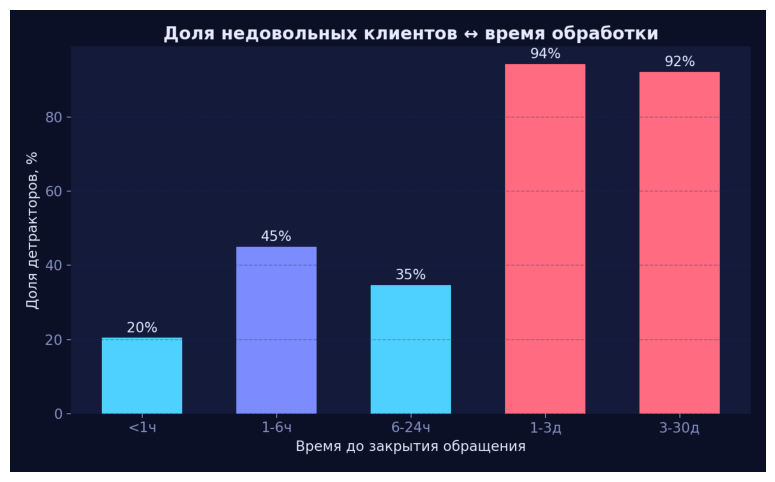

In [6]:
img = plt.imread('images/02_processing_time_vs_detractors.png')
plt.figure(figsize=(10, 6)); plt.imshow(img); plt.axis('off'); plt.show()

**Подтверждена, с сильным эффектом.** rho = −0.47 (p < 0.001) — умеренно-сильная отрицательная связь. Обращения, закрытые в течение часа, дают всего 20% недовольных, а те, что тянутся 1-3 дня — 94%.

**Но осторожно с причинностью.** Направление может быть и обратным: не "долгое ожидание злит клиента", а "изначально сложные/спорные случаи и решаются дольше, и вызывают больше недовольства" — оба фактора растут из одной причины (сложность кейса), а не один из другого. Для продукта это не отменяет вывод — SLA всё равно стоит ужесточать, — но не стоит обещать бизнесу, что просто "быстрее закрывать тикеты" линейно поднимет оценки на ту же величину.

### H2. Удовлетворённость системно различается между клиентскими сегментами

В данных есть официальная сегментация банка (`segment_name`: Защищённые / Малодоходные / Доходные / Высокодоходные без ПМ / Высокодоходные с ПМ) — по сути, прокси дохода и ценности клиента. Проверяю, действительно ли более "дорогой" сегмент получает более довольного клиента, а не наоборот.

In [7]:
order = ['Защищенные', 'Малодоходные', 'Доходные', 'Высокодоходные без ПМ', 'Высокодоходные с ПМ']
seg_stats = df.groupby('segment_name', observed=True)['mark'].agg(['mean', 'count']).reindex(order)
print(seg_stats)

groups = [g['mark'].dropna().values for _, g in df.dropna(subset=['segment_name']).groupby('segment_name', observed=True)]
f_stat, p = f_oneway(*groups)
print(f'\nANOVA: F = {f_stat:.1f}, p = {p:.2e}')

                           mean  count
segment_name                          
Защищенные             3.126537   1383
Малодоходные           3.224568  15964
Доходные               3.368777  22157
Высокодоходные без ПМ  3.887510   2418
Высокодоходные с ПМ    4.060498   1686

ANOVA: F = 131.6, p = 6.01e-112


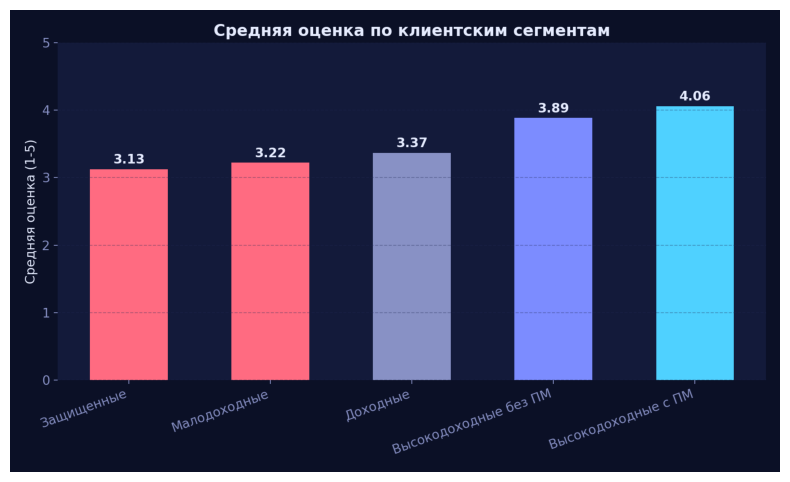

In [8]:
img = plt.imread('images/09_segment_satisfaction.png')
plt.figure(figsize=(10, 6)); plt.imshow(img); plt.axis('off'); plt.show()

**Подтверждена, с чёткой монотонной зависимостью.** Оценка растёт от 3.13 (Защищённые) до 4.06 (Высокодоходные с ПМ) практически без исключений (ANOVA F = 131.6, p < 0.001). Это согласуется и с отдельной проверкой по флагам `influencer_flg`/`subscription_important_flg` — там та же картина: клиенты с более высоким статусом стабильно довольнее.

Вероятная причина не "более обеспеченные люди мягче", а разница в уровне обслуживания: у более ценных для банка сегментов, скорее всего, выделенная линия поддержки и более быстрая обработка обращений. Для бизнеса это не повод расслабляться по премиум-сегменту, а сигнал — понять, какая именно часть этого сервиса переносима на массовый сегмент дешевле, чем кажется.

### H3. Доля недовольных клиентов сильно различается между площадками — включая площадки, которые не являются "витриной отзывов"

Исходно казалось логичным сравнить только banki.ru и sravni.ru — два крупнейших источника. Но всего источников 20, и если посмотреть на все, картина куда интереснее, чем "один агрегатор злее другого".

In [9]:
vc = df['review_source'].value_counts()
top5 = vc.head(5).index.tolist()
print('Топ-5 площадок по объёму:', top5)
print(f'На них приходится {vc.head(5).sum()} из {len(df)} отзывов ({vc.head(5).sum()/len(df)*100:.1f}%)')

df['source_grp'] = df['review_source'].where(df['review_source'].isin(top5), 'остальные (14 площадок)')
grp = df.groupby('source_grp')['is_detractor'].agg(['mean', 'count']).reindex(top5 + ['остальные (14 площадок)'])
print()
print(grp)

table = pd.crosstab(df['source_grp'], df['review_emotion'])
chi2, p, dof, exp = chi2_contingency(table)
print(f'\nchi2 = {chi2:.1f}, p = {p:.2e}, dof = {dof}')

Топ-5 площадок по объёму: ['banki.ru', 'sravni.ru', 'пульс', 'otzovik', 'нет']
На них приходится 54504 из 56820 отзывов (95.9%)

                             mean  count
source_grp                              
banki.ru                 0.359883  48224
sravni.ru                0.198249   3541
пульс                    0.995313   1280
otzovik                  0.750292    857
нет                      1.000000    602
остальные (14 площадок)  0.743523   2316

chi2 = 5315.2, p = 0.00e+00, dof = 5


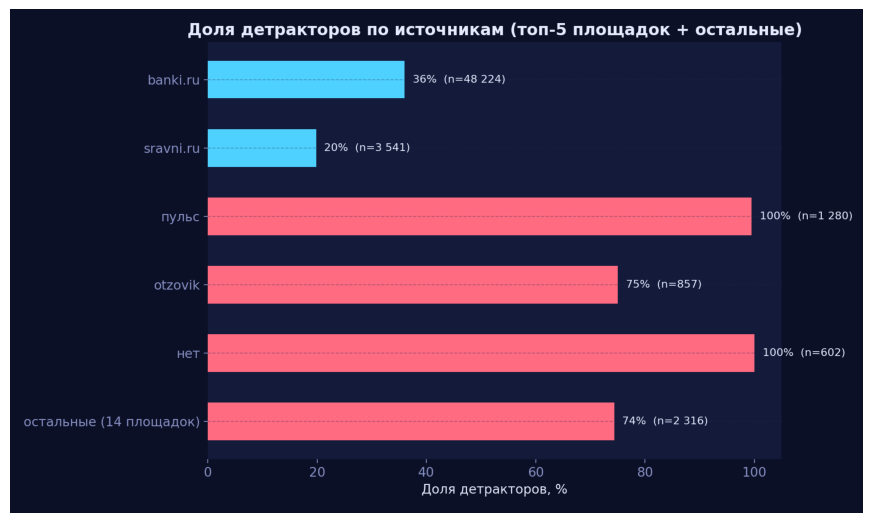

In [10]:
img = plt.imread('images/10_platform_breakdown.png')
plt.figure(figsize=(11, 7)); plt.imshow(img); plt.axis('off'); plt.show()

**Подтверждена, но не в том виде, в котором формулировалась исходно.** Разница между площадками огромная (chi2 = 5315, p < 0.001) — но самое сильное разделение проходит не между banki.ru (36% детракторов) и sravni.ru (20%), а между *классическими витринами отзывов* и *каналами, куда попадают уже готовые жалобы*:

- **`пульс`** — 99.5% детракторов (1 280 отзывов) — судя по всему, не площадка для впечатлений, а канал эскалации именно жалоб.
- **записи без указанного источника (`нет`)** — 100% детракторов (602 отзыва) — вероятно, обращения, заведённые через внутренние каналы поддержки, а не публикации на внешней площадке.
- **otzovik** — 75% детракторов (857 отзывов) — тоже площадка, куда исторически чаще идут именно с претензией.

Вывод: если банк хочет мониторить именно репутацию (что о нас думают в среднем), считать долю детракторов по всем 20 источникам смешанно — методологическая ошибка: `пульс` и безымянные обращения утянут метрику вниз не потому, что сервис хуже, а потому что это разные по природе каналы. banki.ru и sravni.ru — ближе всего к "витрине мнений", остальное — преимущественно каналы работы с претензиями.

### H4. Доля решённых обращений среди недовольных клиентов различается по направлениям бизнеса

Раз `solution_flg` — это метка охвата поддержки, а не повторная оценка, разумно спросить не "решение поднимает оценку?" (это на этих данных не проверить), а "одинаково ли поддержка справляется с жалобами в разных направлениях бизнеса?" Это уже операционный, проверяемый вопрос.

In [11]:
neg = df[df['is_detractor'] == 1]
bl = neg.groupby('business_line').agg(n=('is_detractor', 'size'),
                                       resolved_share=('solution_flg', lambda s: (s == 'проблема решена').mean()))
bl = bl[bl['n'] >= 300].sort_values('resolved_share')
print(bl)

sub = neg[neg['business_line'].isin(bl.index)]
table = pd.crosstab(sub['business_line'], sub['solution_flg'])
chi2, p, dof, exp = chi2_contingency(table)
print(f'\nchi2 = {chi2:.1f}, p = {p:.2e}')

                           n  resolved_share
business_line                               
Не определено            594        0.008418
mobile                   697        0.008608
премиальные сервисы      465        0.458065
ипотека                  396        0.462121
прочие продукты          900        0.510000
нефинансовые продукты    523        0.520076
автокредит               911        0.534577
кредитные карты         2253        0.607634
кредит наличными         482        0.609959
депозитные продукты    10604        0.634478
инвестиции              1993        0.650276
страховая               1219        0.725185
sme                      680        0.742647

chi2 = 2178.1, p = 0.00e+00


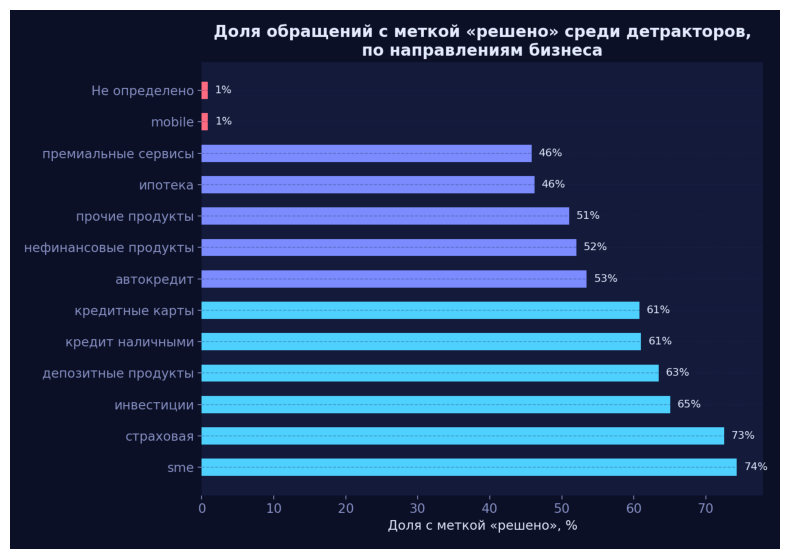

In [12]:
img = plt.imread('images/11_resolution_by_business_line.png')
plt.figure(figsize=(10, 7)); plt.imshow(img); plt.axis('off'); plt.show()

**Подтверждена, с драматическим разбросом.** Доля детракторов с меткой "решено" колеблется от **0.9%** (mobile) до **74%** (sme) — направления, где претензии почти никогда не доходят до статуса "решено", соседствуют с направлениями, где это происходит в трёх случаях из четырёх (chi2 = 2178, p < 0.001).

Это не обязательно значит, что в mobile жалобы игнорируют — возможно, там просто другой процесс обработки, не фиксируемый через тот же флаг. Но именно поэтому это сильный кандидат на проверку у владельца процесса: либо это реальный пробел в охвате поддержки для мобильного канала, либо разрыв в самих данных (метка не проставляется для этого канала физически) — в обоих случаях стоит разбираться, потому что сейчас непонятно, доходит ли жалоба на мобильное приложение до кого-то живого.

### H5. Новые клиенты (стаж < 3 месяцев) менее удовлетворены, чем действующие

In [13]:
new = df[df['new_flg'] == 1]['mark'].dropna()
old = df[df['new_flg'] == 0]['mark'].dropna()
t, p = ttest_ind(new, old, equal_var=False)
print(f'Новые клиенты: среднее = {new.mean():.3f}, n = {len(new):,}'.replace(',', ' '))
print(f'Действующие клиенты: среднее = {old.mean():.3f}, n = {len(old):,}'.replace(',', ' '))
print(f'Welch t-test p = {p:.2e}')

Новые клиенты: среднее = 2.952  n = 942
Действующие клиенты: среднее = 3.373  n = 42 666
Welch t-test p = 7.14e-11


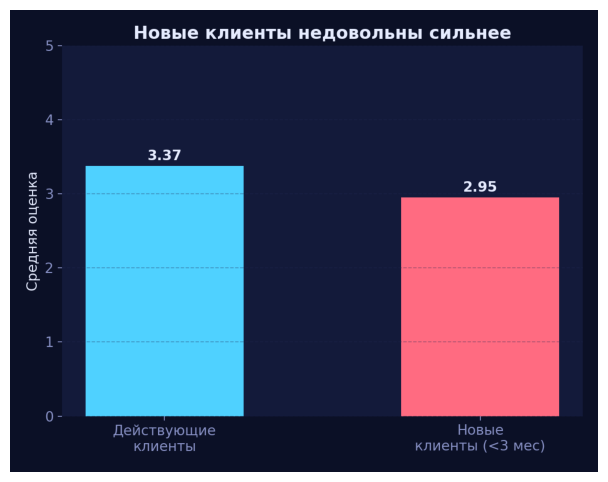

In [14]:
img = plt.imread('images/08_new_vs_existing.png')
plt.figure(figsize=(8, 6)); plt.imshow(img); plt.axis('off'); plt.show()

**Подтверждена.** Разница заметная и статистически значимая: 2.95 у новых клиентов против 3.37 у действующих (p < 0.001). Это классический сигнал про **онбординг** — первое впечатление от продукта и первые проблемы бьют по оценке сильнее, чем у клиентов, которые уже "притёрлись" к банку. Разумная гипотеза для дальнейшей проверки: усиленное сопровождение первых 3 месяцев (проактивная поддержка, более быстрый SLA именно для новых клиентов) может дать непропорционально большой эффект на итоговую удовлетворённость.

## 3. Где именно теряем клиентов: темы и направления

In [15]:
theme_stats = df.groupby('review_theme')['is_detractor'].agg(['mean', 'count'])
theme_stats = theme_stats[theme_stats['count'] >= 300].sort_values('mean', ascending=False)
theme_stats.head(8)

,mean,count
review_theme,,
коммуникации клиентам,0.981297,802
погашение кредитных продуктов,0.965927,1937
карты,0.939061,4365
Не определено,0.918664,1377
обеспечительные меры,0.801382,579
ценные бумаги,0.800948,1055
изменение данных,0.748130,401
aml,0.643979,2101


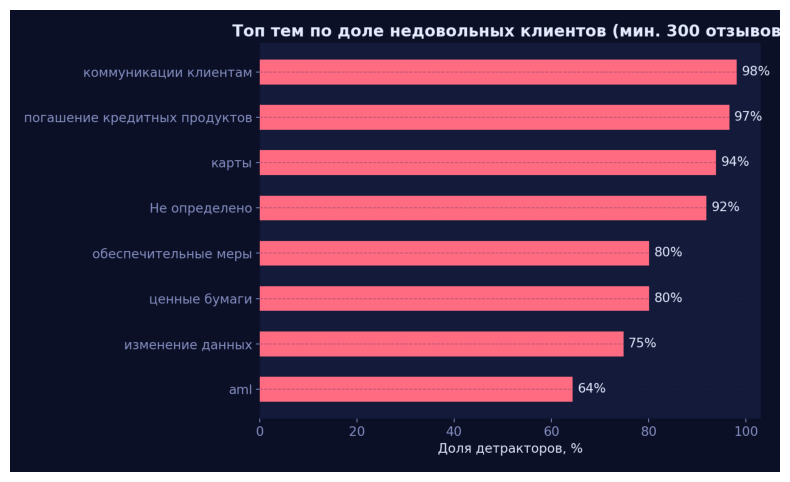

In [16]:
img = plt.imread('images/05_top_negative_themes.png')
plt.figure(figsize=(10, 6)); plt.imshow(img); plt.axis('off'); plt.show()

In [17]:
bl_stats = df.groupby('business_line')['is_detractor'].agg(['mean', 'count'])
bl_stats = bl_stats[bl_stats['count'] >= 300].sort_values('mean', ascending=False)
bl_stats

,mean,count
business_line,,
ипотека,0.977778,405
прочие продукты,0.924974,973
кредит наличными,0.900935,535
mobile,0.894737,779
Не определено,0.851003,698
автокредит,0.798422,1141
кредитные карты,0.730545,3084
депозитные продукты,0.553907,19144
нефинансовые продукты,0.475023,1101


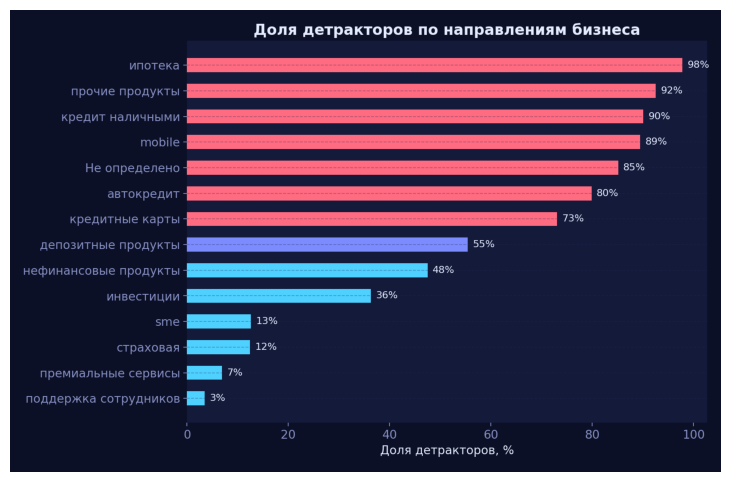

In [18]:
img = plt.imread('images/06_business_line.png')
plt.figure(figsize=(10, 6)); plt.imshow(img); plt.axis('off'); plt.show()

Депозиты — самое большое по объёму направление (19 144 отзыва), но доля детракторов там ниже среднего (55%). Ипотека, кредиты наличными и мобильный банк — небольшие по объёму, но с долей детракторов 90%+ — то есть маленькие, но "болящие" направления, которые стоит разобрать точечно, а не размазывать усилия по всему продуктовому портфелю.

## 4. Динамика за год

In [19]:
monthly = df.groupby(df['review_dttm'].dt.to_period('M'))['is_detractor'].agg(['mean', 'count'])
monthly

,mean,count
review_dttm,,
2025-01,0.457177,7531
2025-02,0.427068,6938
2025-03,0.341444,6247
2025-04,0.309784,6030
2025-05,0.350302,4970
2025-06,0.348646,4876
2025-07,0.369900,5123
2025-08,0.441545,4790
2025-09,0.419912,4520


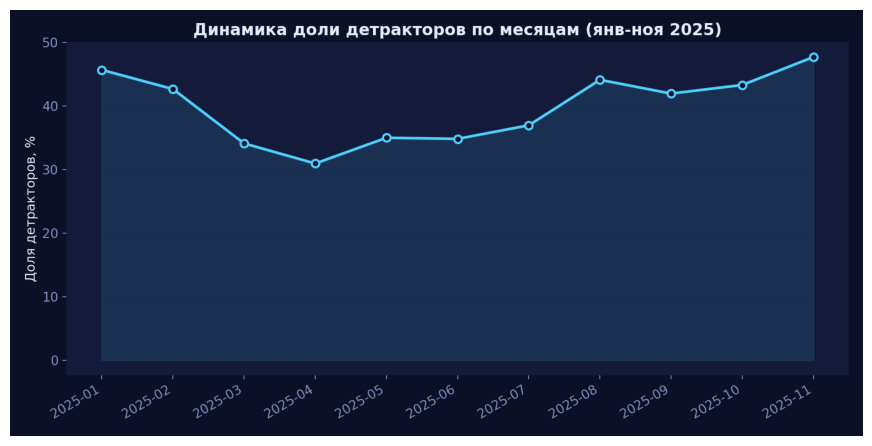

In [20]:
img = plt.imread('images/07_monthly_trend.png')
plt.figure(figsize=(11, 6)); plt.imshow(img); plt.axis('off'); plt.show()

Доля детракторов держится в диапазоне 31-48% весь год без резких обвалов, с минимумом в апреле (31%) и ростом к концу года (август-октябрь — 42-44%). Ноябрь не показателен — в выборке только 5 дней месяца (данные обрываются 5 ноября). Разовых "катастроф" вроде сбоя после обновления в данных не видно — это, скорее, медленный тренд к концу года, который стоит держать в поле зрения, но не поводом для алармы.

## 5. Итоговые выводы и рекомендации

**Что подтвердилось:**
1. Скорость закрытия обращения сильно связана с оценкой (rho = −0.47) — SLA имеет значение, хотя часть эффекта, вероятно, объясняется сложностью самого кейса, а не только ожиданием.
2. Удовлетворённость монотонно растёт с ценностью клиентского сегмента (3.13 → 4.06) — вероятно, за счёт уровня обслуживания, а не характера клиентов.
3. Доля детракторов сильно различается между источниками, но главное разделение — не между двумя крупными агрегаторами, а между "витринами мнений" (banki.ru, sravni.ru) и каналами эскалации жалоб (`пульс`, безымянные обращения) — 99-100% детракторов там ожидаемы по природе канала, не по качеству сервиса.
4. Охват поддержки (доля "решённых" среди жалоб) различается по направлениям бизнеса драматически — от 0.9% (mobile) до 74% (sme) — конкретная операционная точка для разбора с владельцем процесса.
5. Новые клиенты (стаж < 3 мес.) заметно менее довольны действующих (2.95 vs 3.37) — сигнал про важность онбординга.

**Рекомендации для продукта:**
- Приоритизировать сокращение времени обработки для направлений с высокой долей детракторов и большим объёмом — в первую очередь кредитные карты (3 084 отзыва, 73% недовольных) и мобильный банк (779 отзывов, 89% недовольных), а не ипотеку (самая высокая доля недовольства, но всего 405 отзывов — меньше рычаг влияния на общую метрику).
- Разобраться с провалом охвата поддержки в mobile (0.9% решённых обращений среди жалоб) — понять, реальный это пробел процесса или артефакт того, как фиксируются данные для этого канала.
- Изучить, что именно в обслуживании высокодоходных сегментов даёт разницу в 0.9 балла с защищёнными клиентами, и протестировать перенос 1-2 практик на массовый сегмент.
- Не считать долю детракторов "средней температурой по больнице" по всем 20 источникам сразу — разделять витрины мнений и каналы эскалации жалоб, иначе репутационная метрика будет искусственно занижена.
- Усилить сопровождение новых клиентов в первые 3 месяца — судя по разнице в оценках, это точка наибольшей уязвимости лояльности.

---

*Данные: датасет отзывов Т-Банка с внешних платформ и соцсетей за январь-ноябрь 2025 (кейс Т-Интенсива по продуктовой аналитике, лето 2026). Методология: описательная статистика, тест Спирмена, Манна-Уитни, ANOVA, хи-квадрат — на уровне значимости 0.05.*